# mapping

### qasmbench-large

In [2]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/qasmbench-large"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  526.454545   922.818182
1         cirq.csv  750.045455  1153.318182
2         qmap.csv  507.409091   925.818182
3       pytket.csv  587.954545  1028.772727
4          eoh.csv  519.954545   897.681818
5    funsearch.csv  521.818182   917.681818
6        Reevo.csv  498.363636   922.181818
7   Randsample.csv  510.818182   913.318182
8     mcts-ahd.csv  521.545455   921.636364
9   hill_climb.csv  590.545455   996.500000
10       sabre.csv  577.772727  1066.909091


### queko 16qbt

In [4]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  586.155556   975.155556
1         cirq.csv  824.711111  1150.033333
2         qmap.csv  845.011111  1293.944444
3       pytket.csv  774.811111  1179.688889
4          eoh.csv  795.444444  1137.533333
5    funsearch.csv  793.777778  1314.900000
6        Reevo.csv  617.166667  1076.633333
7   Randsample.csv  622.333333  1063.833333
8     mcts-ahd.csv  747.844444  1265.511111
9   hill_climb.csv  780.888889  1327.255556
10       sabre.csv  604.111111   981.522222


In [5]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-16qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 28.93                  15.21
      qmap                 30.63                  24.64
    pytket                 24.35                  17.34
       eoh                 26.31                  14.27
 funsearch                 26.16                  25.84
     Reevo                  5.02                   9.43
Randsample                  5.81                   8.34
  mcts-ahd                 21.62                  22.94
hill_climb                 24.94                  26.53
     sabre                  2.97                   0.65
Average Swap Improvement:  19.67%
Average Depth Improvement: 16.52%


### queko 54qbt

In [6]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621'
 '78665932401991966862754433417993860792272472366534394613604967066333009863656001114470168978528timeout44697729414094566576518469571331402476784335676730596090231051604777445413571249254773902673526484468590412477758534122177855985timeout91497327299042251163timeout30561171244711363519303521177846447986457484252385161239397255942556485767246684490421973771342324479122'] to numeric

Preview of the data:
      source_file    swap_count  final_depth
0      qpilot.csv   5670.277778  2745.900000
1        cirq.csv  10111.922222  4565.433333
2  

In [7]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-54qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
    qpilot                  0.00                   0.00
      cirq                 43.92                  39.85
      qmap                 54.37                  21.46
       eoh                  9.96                   6.80
 funsearch                  8.50                   6.83
     Reevo                 -3.93                  -3.43
Randsample                 -0.81                  -1.36
  mcts-ahd                  7.05                   4.97
hill_climb             

### queko 81qbt

In [8]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Convert columns to numeric and force errors to NaN
            df[columns_to_mean] = df[columns_to_mean].apply(
                pd.to_numeric, errors='coerce'
            )

            means = df[columns_to_mean].mean(skipna=True).to_dict()
            means['source_file'] = file_name
            summary_data.append(means)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]

print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv  12347.500000  3652.200000
1         cirq.csv  18258.522222  5244.800000
2         qmap.csv  25539.500000  4818.633333
3       pytket.csv  18443.306818  7544.625000
4          eoh.csv  13889.877778  4034.800000
5    funsearch.csv  13403.833333  3924.344444
6        Reevo.csv  11831.377778  3519.511111
7   Randsample.csv  12177.377778  3589.288889
8     mcts-ahd.csv  13260.422222  3893.244444
9   hill_climb.csv  13632.055556  3965.888889
10       sabre.csv  14463.044444  4984.077778


In [9]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/queko-bss-81qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "Reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '29066timeout27231730922303326681784420047448614028193691568220852274601337411867484212699275224552442626337364233088699651748212071timeout31953307217914949024397433335409149522654786681351825822389821403197724230105161396330693142758121205002647021066111421845115525916431438260271218532558390179977677144832891219298300321214122726532226519424823787166006831185012950424885245641947313337245622830715135141112095827640298381679529015' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
    qpilot                  0.00                   0.00
      cirq                 32.37                  30.37
      qmap                 51.65                  24.21
       eoh                 11.10                   9.48
 funsearch                  7.88                   6.93
     Reevo                 -4.36                  -3.77
Randsample                 -1.40                  -1.75
  mcts-ahd                  6.88                  

### plots queko-16qbt

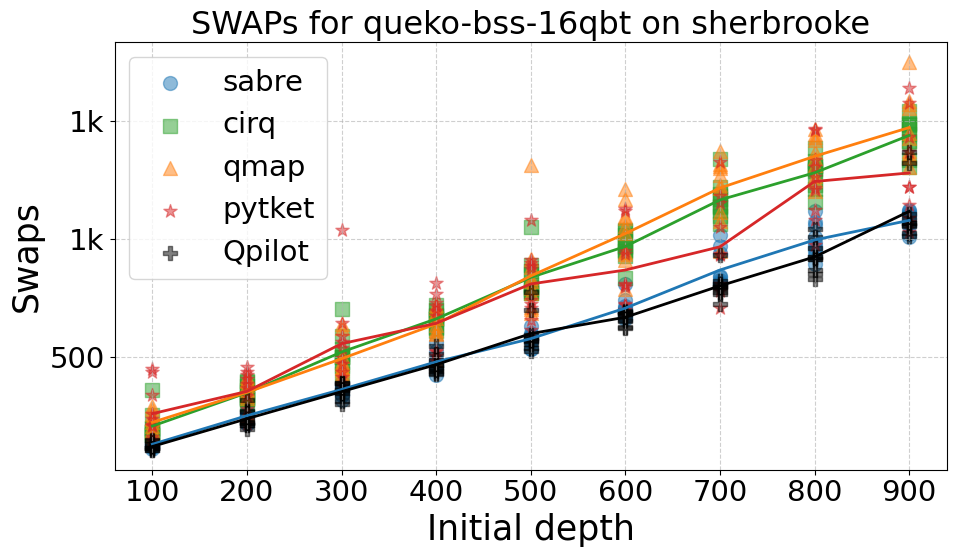

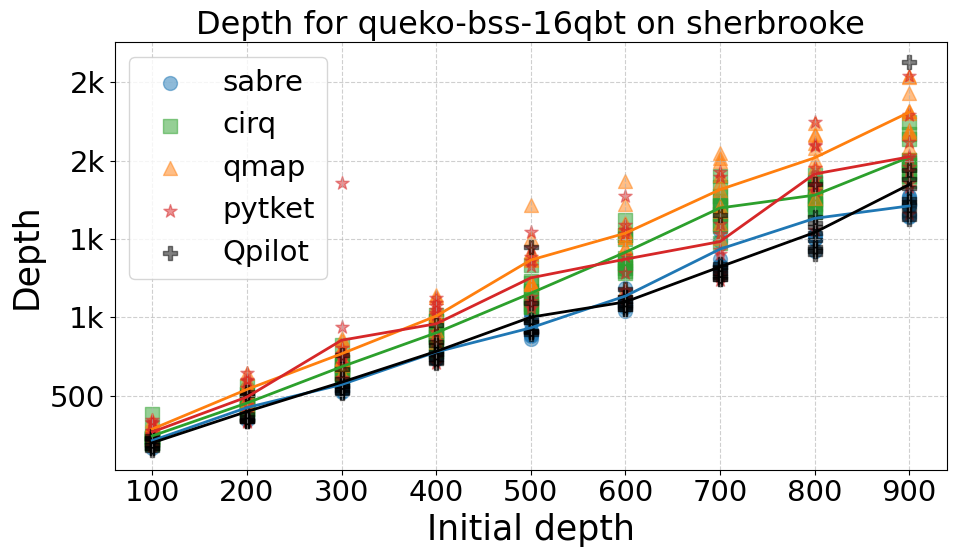

In [3]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

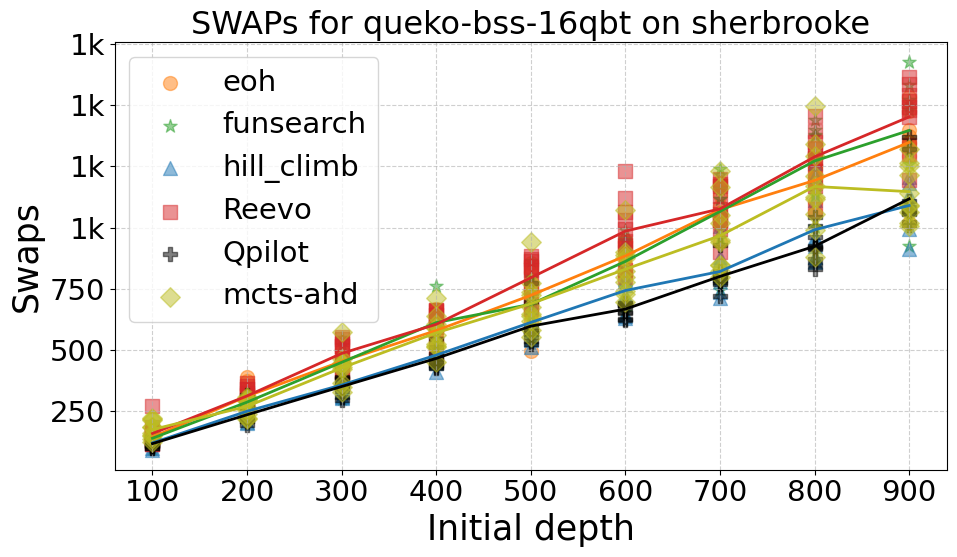

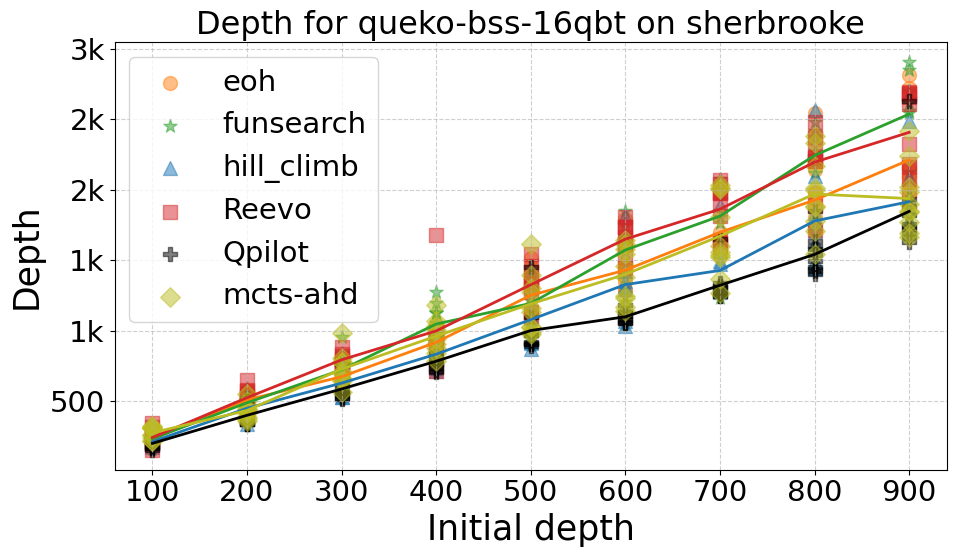

In [3]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/funsearch.csv",
    "hill_climb": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/hill_climb.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

### plots queko-54qbt

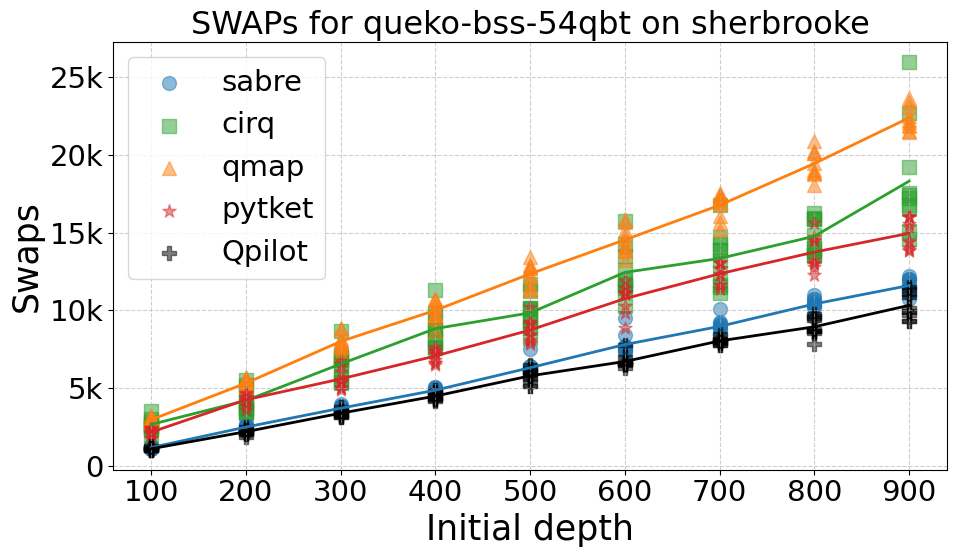

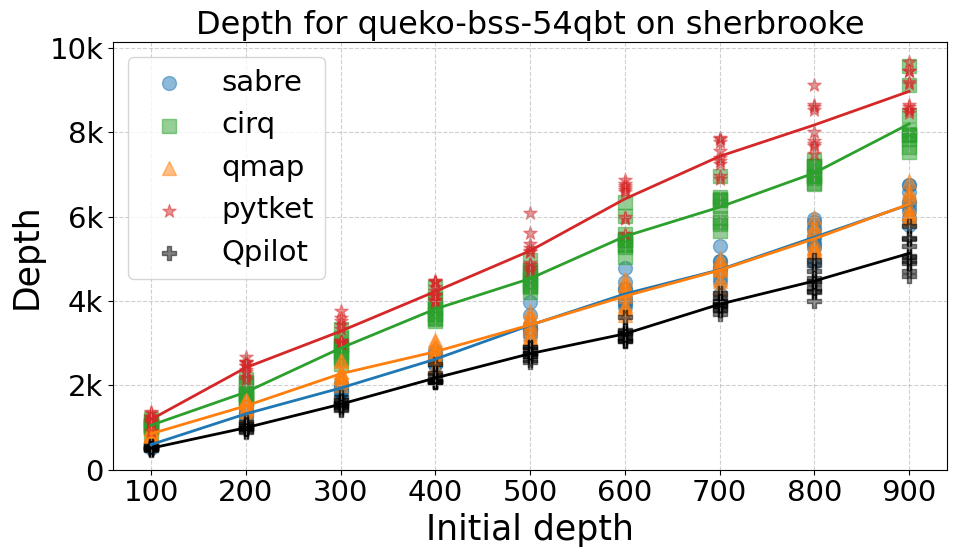

In [1]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

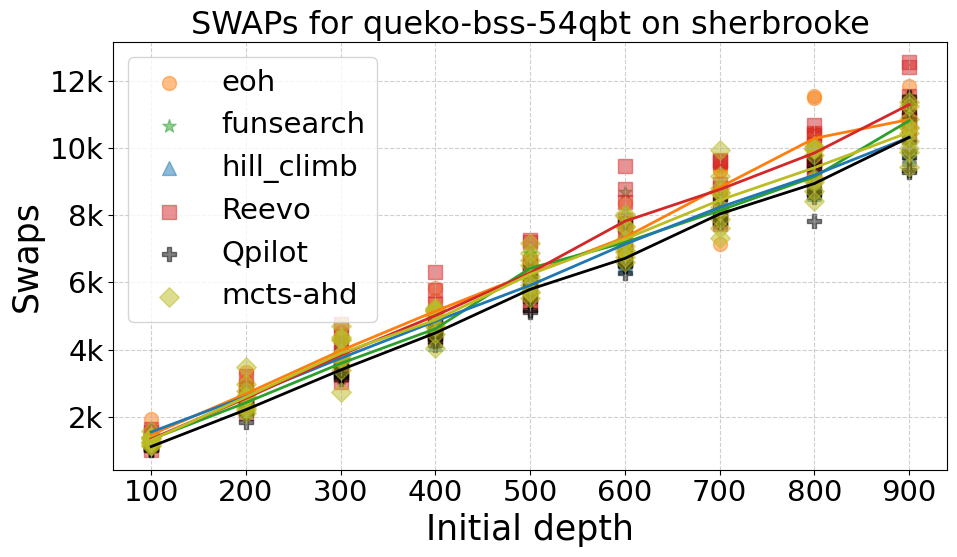

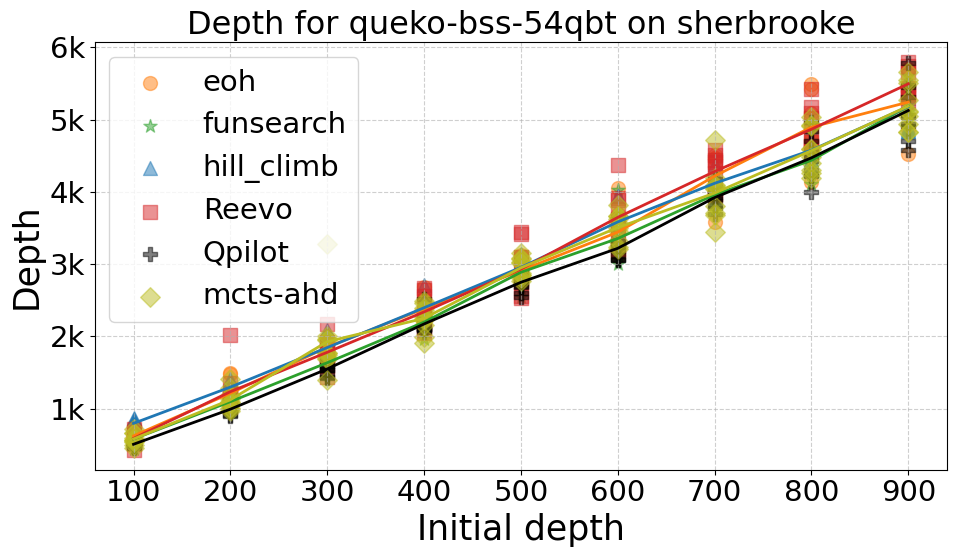

In [2]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/funsearch.csv",
    "hill_climb": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/hill_climb.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

### plots queko-81qbt

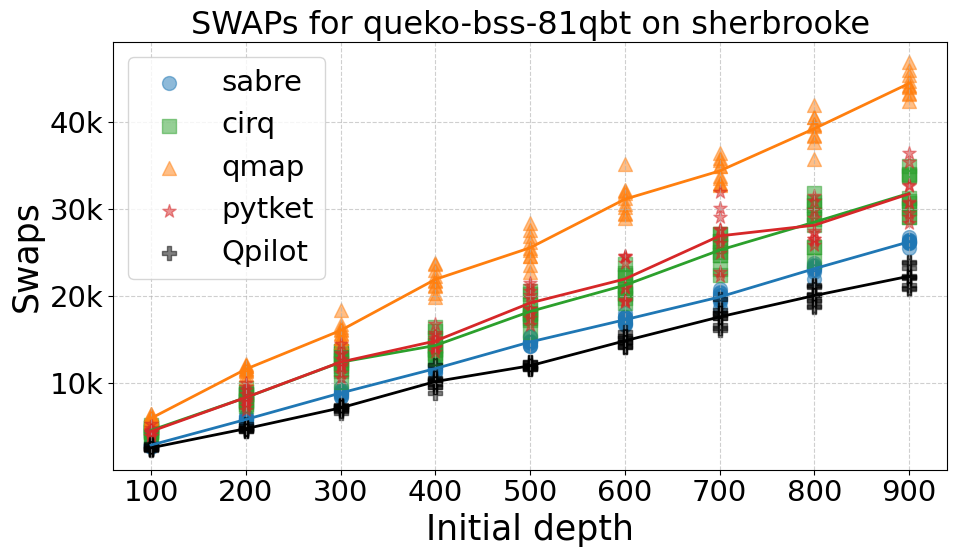

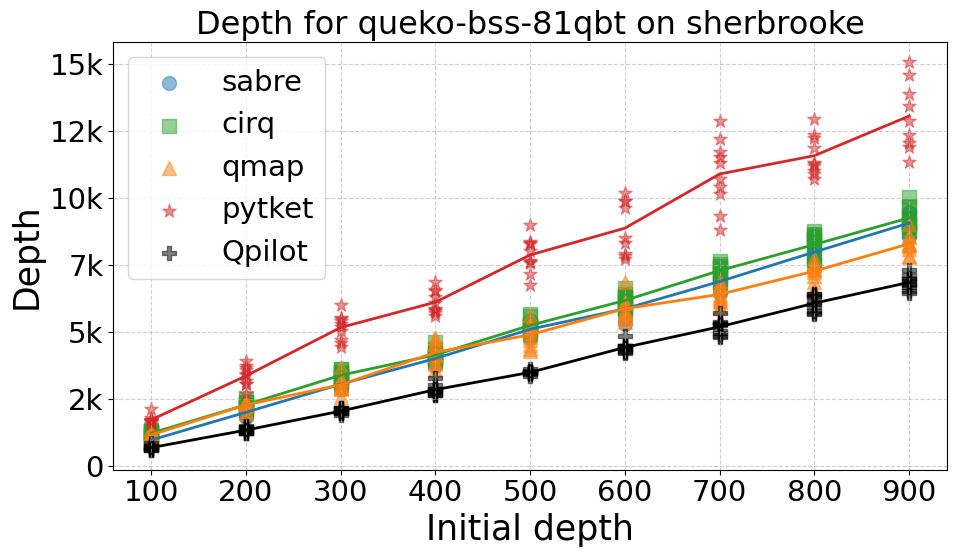

In [9]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

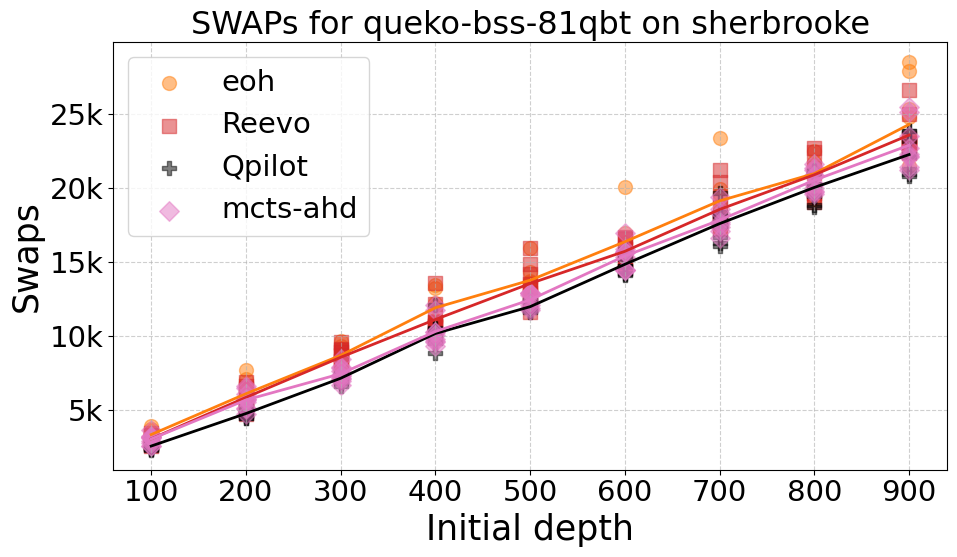

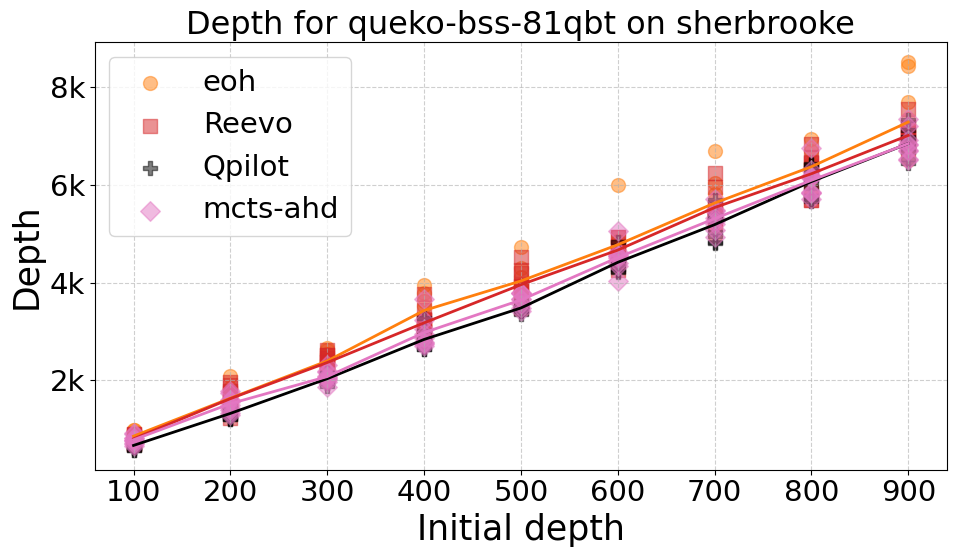

In [1]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/eoh.csv",
    "Reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/Reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/{BENCHMARK}/mcts-ahd.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## summary

## Benchmark Results: queko16qbt

### Raw Performance Metrics
| Source File | Swap Count | Final Depth |
| :--- | :--- | :--- |
| `qpilot.csv` | 586.155556 | 975.155556 |
| `cirq.csv` | 824.711111 | 1150.033333 |
| `qmap.csv` | 845.011111 | 1293.944444 |
| `pytket.csv` | 774.811111 | 1179.688889 |
| `eoh.csv` | 733.298851 | 1185.344828 |
| `funsearch.csv` | 745.280899 | 1302.831461 |
| `Reevo.csv` | 795.755556 | 1332.988889 |
| `Randsample.csv` | 725.363636 | 1353.522727 |
| `mcts-ahd.csv` | 693.611111 | 1173.855556 |
| `hill_climb.csv` | 603.090909 | 1065.090909 |
| `sabre.csv` | 604.111111 | 981.522222 |

### Improvement Percentages
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :--- | :--- |
| **cirq** | 28.93 | 15.21 |
| **qmap** | 30.63 | 24.64 |
| **pytket** | 24.35 | 17.34 |
| **eoh** | 20.07 | 17.73 |
| **funsearch** | 21.35 | 25.15 |
| **Reevo** | 26.34 | 26.84 |
| **Randsample** | 19.19 | 27.95 |
| **mcts-ahd** | 15.49 | 16.93 |
| **hill_climb** | 2.81 | 8.44 |
| **sabre** | 2.97 | 0.65 |

---

## Benchmark Results: queko54qbt

### Raw Performance Metrics
| Source File | Swap Count | Final Depth |
| :--- | :--- | :--- |
| `qpilot.csv` | 5670.277778 | 2745.900000 |
| `eoh.csv` | 5995.278481 | 2819.835443 |
| `Reevo.csv` | 6249.976471 | 2988.976471 |
| `mcts-ahd.csv` | 6060.533333 | 2897.966667 |
| `hill_climb.csv` | 5989.939759 | 2993.265060 |
| `cirq.csv` | 10111.922222 | 4565.433333 |
| `qmap.csv` | 12426.188889 | 3496.344444 |
| `sabre.csv` | 6378.322222 | 3398.655556 |

### Improvement Percentages
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :--- | :--- |
| **cirq** | 43.92 | 39.85 |
| **qmap** | 54.37 | 21.46 |
| **eoh** | 5.42 | 2.62 |
| **Reevo** | 9.28 | 8.13 |
| **mcts-ahd** | 6.44 | 5.25 |
| **hill_climb** | 5.34 | 8.26 |
| **sabre** | 11.10 | 19.21 |

---

## Benchmark Results: queko81qbt

### Raw Performance Metrics
| Source File | Swap Count | Final Depth |
| :--- | :--- | :--- |
| `qpilot.csv` | 12347.500000 | 3652.200000 |
| `eoh.csv` | 13101.194805 | 3822.883117 |
| `Reevo.csv` | 13174.858824 | 3859.282353 |
| `mcts-ahd.csv` | 12583.253012 | 3680.855422 |
| `cirq.csv` | 18258.522222 | 5244.800000 |
| `qmap.csv` | 25539.500000 | 4818.633333 |
| `pytket.csv` | 18443.306818 | 7544.625000 |
| `sabre.csv` | 14463.044444 | 4984.077778 |

### Improvement Percentages
| Method | Swap Improvement (%) | Depth Improvement (%) |
| :--- | :--- | :--- |
| **eoh** | 5.75 | 4.46 |
| **Reevo** | 6.28 | 5.37 |
| **mcts-ahd** | 1.87 | 0.78 |
| **cirq** | 32.37 | 30.37 |
| **qmap** | 51.65 | 24.21 |
| **sabre** | 14.63 | 26.72 |